In [1]:
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
mnist = fetch_openml("mnist_784", version=1, as_frame=False)

X = mnist.data
y = mnist.target.astype(int)

In [3]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.3,stratify=y)

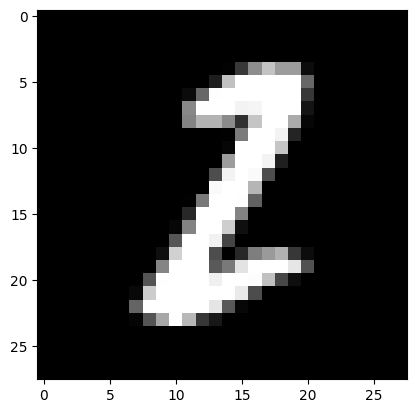

In [4]:
plt.imshow(X_train[1000].reshape(28, 28), cmap="gray")

In [5]:
#Get the dimensionality
print(X_train.ndim)
print(X_train.shape)

2
(49000, 784)


In [6]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [7]:
X_train_scaled = scaler.fit_transform(X_train)

In [8]:
X_test_scaled = scaler.transform(X_test)

In [9]:
X_train_scaled.shape


(49000, 784)

In [10]:
import numpy as np

class KNN:
    def __init__(self, k = 5):
        self.k = k

    def fit(self, X_train_scaled, y_train):
        self.X_train = X_train_scaled
        self.y_train = y_train
        
    def predict_eucliean(self, test_point):
        distances = []
        for i in range(self.X_train.shape[0]):
            dist = 0
            for j in range(self.X_train.shape[1]):
                dist += (test_point[j] - self.X_train[i][j])**2
                
            distances.append(dist**(1/2))

        #now we have the indexes of the X_train get corresponding y_train labels
        distances = np.argsort(distances)
        top_indexes = distances[:self.k]

        #get top_index_labels
        labels = []
        for i in top_indexes:
            labels.append(self.y_train[i])
        

        #now get the indexs and the lables and then put them in the map with freq and get the highest one
        mpp = {}
        for label in labels:
            if label not in mpp:
                mpp[label] = 1
            else:
                mpp[label] += 1
                
        #mpp will look like <key,value> --->  <label,freq>
        #Now get the label of the highest class
        highest_label_mpp = sorted(mpp.items(),key=lambda x:x[1],reverse=True)
        return highest_label_mpp[0][0]
        
    def predict_manhattan(self, test_point):
        distances = []
        for i in range(self.X_train.shape[0]):
            dist = 0
            for j in range(self.X_train.shape[1]):
                dist += abs(test_point[j] - self.X_train[i][j])
                
            distances.append(dist)

        #now we have the indexes of the X_train get corresponding y_train labels
        distances = np.argsort(distances)
        top_indexes = distances[:self.k]

        #get top_index_labels
        labels = []
        for i in top_indexes:
            labels.append(self.y_train[i])
        

        #now get the indexs and the lables and then put them in the map with freq and get the highest one
        mpp = {}
        for label in labels:
            if label not in mpp:
                mpp[label] = 1
            else:
                mpp[label] += 1
                
        #mpp will look like <key,value> --->  <label,freq>
        #Now get the label of the highest class
        highest_label_mpp = sorted(mpp.items(),key=lambda x:x[1],reverse=True)
        return highest_label_mpp[0][0]
        
    def get_y_pred_e(self,points):
        ans = []
        for i in range(len(points)):
            label = self.predict_eucliean(points[i])
            ans.append(label)
            
        return ans
        
    def get_y_pred_m(self,points):
        ans = []
        for i in range(len(points)):
            label = self.predict_manhattan(points[i])
            ans.append(label)
            
        return ans



In [15]:
errors = []
k = [1,3,5,7,9,11]

for k_value in k:
    cnt = 0
    knn = KNN(k_value)
    knn.fit(X_train_scaled[:100],y_train[:100])
    for i in range(100):
        label_predicted = knn.predict_eucliean(X_test_scaled[i])
        correct_label = y_test[i]

        if label_predicted !=correct_label:
            cnt+=1

    errors.append(cnt/100)

print(errors)



[0.41, 0.4, 0.32, 0.37, 0.41, 0.46]


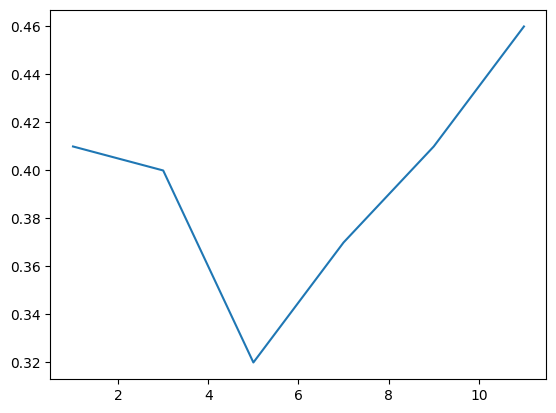

In [16]:
plt.plot(k,errors)

In [17]:
#Comare test accuracy
knn = KNN(5)
knn.fit(X_train_scaled[:5000],y_train[:5000])

In [ ]:
print(knn.get_y_pred_e(X_test[:100]))
print(knn.get_y_pred_m(X_test[:100]))

[7, 8, 2, 2, 3, 8, 2, 1, 6, 8, 9, 5, 8, 9, 8, 8, 0, 0, 0, 1, 8, 4, 0, 8, 4, 0, 5, 9, 8, 4, 0, 7, 8, 2, 0, 7, 8, 3, 8, 7, 9, 5, 2, 0, 0, 3, 9, 4, 6, 8, 6, 0, 5, 8, 3, 0, 1, 7, 6, 2, 9, 0, 8, 8, 9, 3, 6, 8, 0, 8, 8, 2, 7, 8, 3, 2, 1, 6, 8, 5, 1, 1, 8, 8, 2, 0, 8, 5, 9, 2, 8, 0, 4, 1, 0, 7, 8, 1, 0, 6]
